# 19. Настройка гиперпараметров: кросс-валидация LightGBM и поиск Optuna

| | |
|---|---|
| **Уровень** | 3 из 4 — средние данные: полный цикл и типовые случаи (`3_medium`) |
| **Скрипт-источник** | [`19_cv_and_optuna.py`](../19_cv_and_optuna.py) — тот же код, запуск из терминала |
| **Время выполнения** | ≈ 67 с |

**Цель.** Настроить бустинг правильно — оценка по кросс-валидации, умный поиск, честный итог на тесте.

### Чему вы научитесь

- `lgb.cv` с ранней остановкой внутри фолдов
- Пространство поиска в логарифмической шкале
- TPE-сэмплер Optuna
- Итоговое обучение и честная проверка на отложенном тесте

### Данные

`_data.make_houses` — 20 000 квартир, цель — `log(цены)`; 20% — отложенный тест, который не участвует в поиске.

### План

1. **Этап 1.** Данные: 80% для поиска (кросс-валидация), 20% — отложенный тест
2. **Этап 2.** База: параметры по умолчанию, ν = 0.05
3. **Этап 3.** Пространство поиска: размер деревьев, листья, случайность, штрафы — в лог-шкале, где нужно
4. **Этап 4.** Поиск: TPE, 25 запусков (первые 10 — случайные)
5. **Этап 5.** Итог: обучаем на всех 80% с найденным числом деревьев и смотрим тест ОДИН раз

> Ноутбук собран из `examples/3_medium/19_cv_and_optuna.py` командой `python examples/build_notebooks.py`. Чтобы изменить пример, правьте скрипт и пересоберите ноутбук.

## Подготовка

Ячейка ниже находит папку `examples/` (ноутбук можно открыть из любой рабочей папки внутри
репозитория), подключает общий каркас примеров `_common.Example` и учебную библиотеку курса
`gbcourse`. Каркас печатает этапы и выводы, «раскрывает» датасет и показывает графики прямо в
ноутбуке. Выполняйте ячейки сверху вниз: **Run → Run All Cells**.

In [1]:
import sys
from pathlib import Path

EXAMPLES = next(p / "examples" for p in [Path.cwd(), *Path.cwd().parents]
                if (p / "examples" / "_common.py").is_file())
sys.path.insert(0, str(EXAMPLES))
from _common import Example
from _data import make_houses

ex = Example(EXAMPLES / "3_medium/19_cv_and_optuna.py", title="19. Кросс-валидация и Optuna",
             goal="настроить LightGBM поиском с честной итоговой оценкой")

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import optuna
from gbcourse.style import ROLE

optuna.logging.set_verbosity(optuna.logging.WARNING)

## Этап 1. Данные: 80% для поиска (кросс-валидация), 20% — отложенный тест

In [2]:
X, price = make_houses(ex.size(20_000, 4000), seed=19)
y = np.log(price)
ex.describe(X, y, target="log(цена)", source="examples/_data.py → make_houses")
n = len(y)
perm = np.random.default_rng(0).permutation(n)
dev, te = perm[: int(0.8 * n)], perm[int(0.8 * n):]
rmse = lambda a, b: float(np.sqrt(np.mean((a - b) ** 2)))


def cv_score(params):
    """5-кратная CV с ранней остановкой внутри фолдов; возвращает RMSE и лучшее число деревьев."""
    ds = lgb.Dataset(X.iloc[dev], y[dev], free_raw_data=False)
    res = lgb.cv({"objective": "regression", "metric": "rmse", "verbose": -1, "seed": 0, **params}, ds,
                 num_boost_round=5000, nfold=5, stratified=False, seed=0,
                 callbacks=[lgb.early_stopping(100, verbose=False)])
    curve = res["valid rmse-mean"]
    return float(curve[-1]), len(curve)

   Источник: examples/_data.py → make_houses
   Объектов: 20 000   признаков: 10   память: 1.26 МБ
   Типы признаков: int64 × 5, float64 × 3, category × 2
   Пропуски: кухня 5.0%
   Цель «log(цена)»: среднее 2.059, σ 0.473, мин 0.241, макс 3.551
   Первые строки:


,площадь,комнаты,этаж,этажность,год,до_центра_км,район,парковка,ремонт,кухня,[log(цена)]
0,45.8,1,2,5,1950,12.71,район_02,0,косметический,6.2,1.711633
1,63.6,3,3,9,2009,8.05,район_22,1,косметический,13.2,2.396622
2,44.4,1,11,12,1990,12.72,район_01,0,косметический,5.6,1.733954


## Этап 2. База: параметры по умолчанию, ν = 0.05

In [3]:
base_params = {"learning_rate": 0.05}
with ex.timer("кросс-валидация"):
    base_rmse, base_trees = cv_score(base_params)
print(f"   CV RMSE {base_rmse:.4f} при {base_trees} деревьях")

   ⏱ кросс-валидация: 1.85 с
   CV RMSE 0.0882 при 406 деревьях


## Этап 3. Пространство поиска: размер деревьев, листья, случайность, штрафы — в лог-шкале, где нужно

In [4]:
def objective(trial):
    params = {
        "learning_rate": 0.05,
        "num_leaves": trial.suggest_int("num_leaves", 4, 256, log=True),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 200, log=True),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.4, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.5, 1.0),
        "bagging_freq": 1,
        "lambda_l2": trial.suggest_float("lambda_l2", 1e-3, 100, log=True),
        "cat_smooth": trial.suggest_float("cat_smooth", 1, 100, log=True),
    }
    score, trees = cv_score(params)
    trial.set_user_attr("trees", trees)
    return score

## Этап 4. Поиск: TPE, 25 запусков (первые 10 — случайные)

   ⏱ поиск: 61.93 с
   после  1 запусков лучшая CV RMSE 0.0879
   после  5 запусков лучшая CV RMSE 0.0850
   после 10 запусков лучшая CV RMSE 0.0850
   после 15 запусков лучшая CV RMSE 0.0843
   после 20 запусков лучшая CV RMSE 0.0843
   после 25 запусков лучшая CV RMSE 0.0843


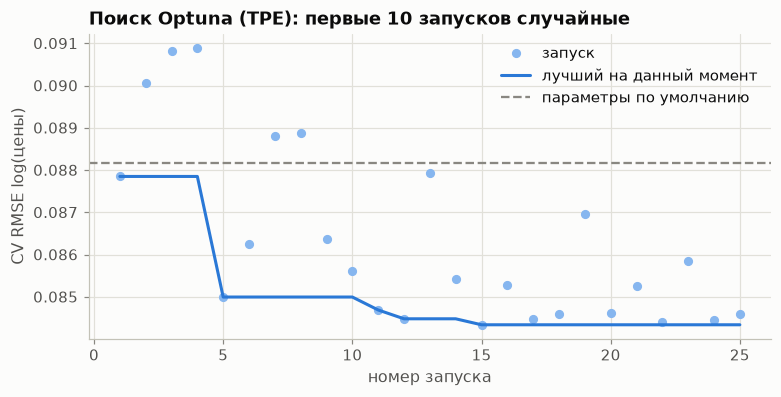

   лучшие параметры: num_leaves=5, min_child_samples=36, feature_fraction=0.464, bagging_fraction=0.767, lambda_l2=25.5, cat_smooth=2.96


In [5]:
study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=0, n_startup_trials=10))
with ex.timer("поиск"):
    study.optimize(objective, n_trials=ex.size(25, 8))
best_curve = np.minimum.accumulate([t.value for t in study.trials])
for k in (1, 5, 10, 15, 20, 25):
    if k <= len(best_curve):
        print(f"   после {k:2d} запусков лучшая CV RMSE {best_curve[k - 1]:.4f}")
fig, ax = plt.subplots(figsize=(8, 3.6))
k = np.arange(1, len(study.trials) + 1)
ax.plot(k, [t.value for t in study.trials], "o", color=ROLE["model_prev"], ms=5, label="запуск")
ax.plot(k, best_curve, color=ROLE["model"], lw=2, label="лучший на данный момент")
ax.axhline(base_rmse, color=ROLE["truth"], ls="--", lw=1.5, label="параметры по умолчанию")
ax.set(xlabel="номер запуска", ylabel="CV RMSE log(цены)", title="Поиск Optuna (TPE): первые 10 запусков случайные")
ax.legend()
ex.finish(fig, "19_optuna_progress")
print("   лучшие параметры: " + ", ".join(f"{k}={v:.3g}" if isinstance(v, float) else f"{k}={v}" for k, v in study.best_params.items()))

## Этап 5. Итог: обучаем на всех 80% с найденным числом деревьев и смотрим тест ОДИН раз

In [6]:
final = {"objective": "regression", "learning_rate": 0.05, "bagging_freq": 1, "verbose": -1, "seed": 0, **study.best_params}
trees = study.best_trial.user_attrs["trees"]
model = lgb.train(final, lgb.Dataset(X.iloc[dev], y[dev]), num_boost_round=int(trees * 1.1))
base_model = lgb.train({"objective": "regression", "learning_rate": 0.05, "verbose": -1, "seed": 0},
                       lgb.Dataset(X.iloc[dev], y[dev]), num_boost_round=int(base_trees * 1.1))
print(f"   тест RMSE: база {rmse(y[te], base_model.predict(X.iloc[te])):.4f}, после поиска {rmse(y[te], model.predict(X.iloc[te])):.4f}")
print(f"   CV RMSE лучшего запуска {study.best_value:.4f} — оценка слегка оптимистична: из многих вариантов выбран лучший")
ex.note("""Число деревьев на всех данных берут чуть больше найденного в CV (данных стало на 25% больше).
Тест не участвовал ни в одном выборе — поэтому его оценке можно верить.""")
ex.done()

   тест RMSE: база 0.0856, после поиска 0.0821
   CV RMSE лучшего запуска 0.0843 — оценка слегка оптимистична: из многих вариантов выбран лучший


> ▸ **Вывод.** Число деревьев на всех данных берут чуть больше найденного в CV (данных стало на 25% больше). Тест не участвовал ни в одном выборе — поэтому его оценке можно верить.

Готово за 65.7 с


## Попробуйте сами

Измените код в ячейках выше и выполните их заново:

1. Добавьте темп обучения в пространство поиска (0.01–0.3, лог-шкала) — что найдёт TPE?
2. Повторите поиск с `optuna.samplers.RandomSampler` при тех же 25 запусках и сравните кривые.
3. Оцените важность гиперпараметров: `optuna.importance.get_param_importances(study)`.

## Что дальше

- **Теория в курсе:** [11 «Настройка»](../../../lessons/lesson_11/README.md), [11.1 «Стратегия»](../../../lessons/lesson_11_1/README.md), [11.2 «CV и Optuna»](../../../lessons/lesson_11_2/README.md).
- **Предыдущий пример:** [18. Своя функция потерь и своя метрика: недооценка в 3 раза дороже переоценки](18_custom_loss_and_metric.ipynb)
- **Следующий пример:** [20. Интерпретация модели с SHAP: от общей картины до одной квартиры](20_shap_interpretation.ipynb)
- **Все примеры:** [examples/README.md](../../README.md)